From Andy:

The first tranche of gridded molefraction files has been recovered and transferred to MSU.

Files are in /work/noaa/co2/andy/Projects/WOMBAT/wombat-v3-forward/3b_transport_tm5/intermediates/runs, for runs r0001 through r0207. TM5 stores these in daily files in output directories named after the job step start time. These start times are spaced by 4 weeks. So:

r0208/output/20200207/molefrac_glb3x2_202002250000_202002260000.nc

is associated with a jobstep that started 2020-02-07, and is a daily average from 0Z on 2020-02-25 to 0Z on 2020-02-26. It has tracers s0016048 through s0017107. These tracer names are decoded in:

/work/noaa/co2/andy/Projects/WOMBAT/wombat-v3-forward/3b_transport_tm5/intermediates/runs/tm5_mapping.csv.

In [29]:
import pdb
import glob
import pandas as pd
import numpy as np
import xarray as xr
import inversion_tools
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

globf = lambda x: [s.split('/')[-1] for s in glob.glob(x)]
pdir  = '/work/noaa/co2/jhollo/processed_transport_data/tm5_tmp'

## First validate outputs at r0042

In [30]:
source, component, region, start, nmonths, pft = \
'bio_resp_tot', 'cos12_2', 1, 2014, 3, 8

fname    = f'{pdir}/{source}_{component}_{region}_{start}_{nmonths}'
mfname   = f'{fname}_mf.nc'
fluxname = f'{fname}_flux.nc'

try:
    if(False): raise FileNotFoundError
    tm5_flux = xr.open_dataset(fluxname)
    print('read flux from file')
    tm5_flux = tm5_flux[list(tm5_flux.data_vars)[0]]
except FileNotFoundError:
    tm5_flux = inversion_tools.read_tm5_flux(source, component, region, start, nmonths, pft=pft)
    tm5_flux.to_netcdf(fluxname)
try:
    if(False): raise FileNotFoundError
    tm5_mf = xr.open_dataset(mfname)
    print('read mf from file')
    tm5_mf = tm5_mf[list(tm5_mf.data_vars)[0]]
except FileNotFoundError:
    tm5_mf   = inversion_tools.read_tm5_mf(source, component, region, start, nmonths, pft=pft)
    tm5_mf.to_netcdf(mfname)

read flux from file
read mf from file


In [31]:
reader  = inversion_tools.Reader('resp', 'cos12_2', quiet=False)
gc_data = reader.read_mf(region=1, start_date='2014-09', end_date='2015-01', pft=8)
gc_flux = reader.read_flux(region=1, start_date='2014-09', end_date='2015-01', pft=8)

---------- reading data for year 2014 ----------
reading daily-mole-fraction_bio_resp_tot_cos12_2_pft08_regionRegion01_2014.nc4...
---------- reading data for year 2015 ----------
reading daily-mole-fraction_bio_resp_tot_cos12_2_pft08_regionRegion01_2015.nc4...
concatenating 2 DataArrays
---------- reading data for year 2014 ----------
reading daily-fluxes_bio_resp_tot_cos12_2_pft08_regionRegion01_2014.nc4...
---------- reading data for year 2015 ----------
reading daily-fluxes_bio_resp_tot_cos12_2_pft08_regionRegion01_2015.nc4...
concatenating 2 DataArrays


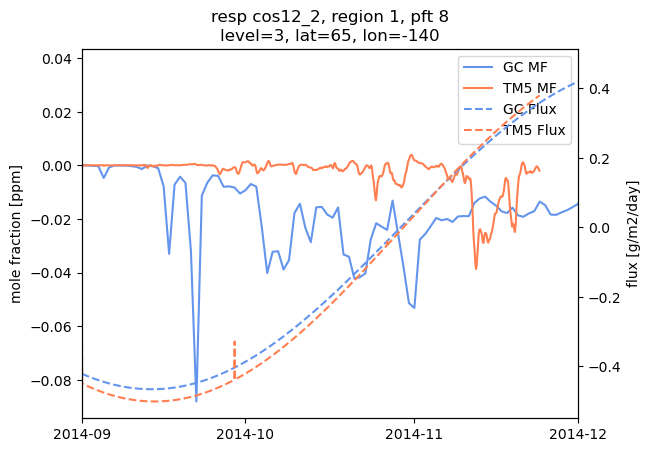

In [67]:
tm5c = 'coral'
gcc = 'cornflowerblue'

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(gc_data.time, gc_data.isel(lev=20).sel(lat=65, lon=-140, method='nearest'), color=gcc, label='GC MF')
ax.plot(tm5_mf.time, tm5_mf.isel(level=20).sel(latitude=65, longitude=-140, method='nearest'), color=tm5c, label='TM5 MF')
ax.plot(gc_data.time[0], [0], '--', color=gcc, label='GC Flux')
ax.plot(tm5_mf.time[0], [0], '--', color=tm5c, label='TM5 Flux')

axf = plt.gca().twinx()
axf.plot(gc_flux.time, gc_flux.sel(lat=65, lon=-140, method='nearest'), '--', color=gcc)
axf.plot(tm5_flux.time, tm5_flux.sel(latitude=65, longitude=-140, method='nearest'), '--', color=tm5c)

ax.set_xlim([np.datetime64('2014-09-01'), np.datetime64('2014-12-01')])
ax.set_title('resp cos12_2, region 1, pft 8\nlevel=3, lat=65, lon=-140')
ax.set_ylabel('mole fraction [ppm]')
axf.set_ylabel('flux [g/m2/day]')
ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
#fig.autofmt_xdate()

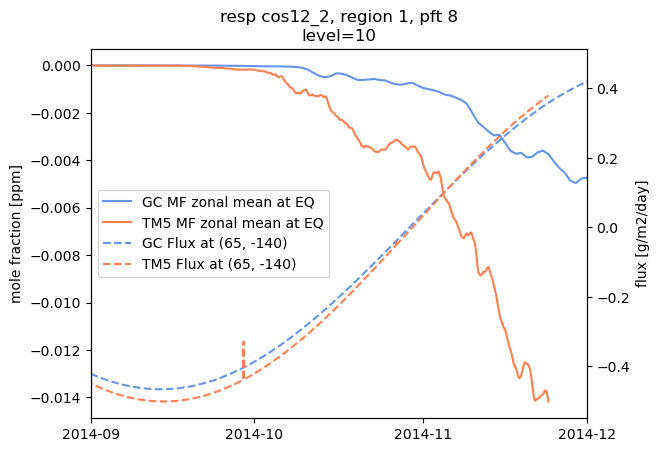

In [64]:
tm5c = 'coral'
gcc = 'cornflowerblue'

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(gc_data.time, gc_data.isel(lev=10).sel(lat=0, method='nearest').mean('lon'), color=gcc, label='GC MF zonal mean at EQ')
ax.plot(tm5_mf.time, tm5_mf.isel(level=10).sel(latitude=0, method='nearest').mean('longitude'), color=tm5c, label='TM5 MF zonal mean at EQ')
ax.plot(gc_data.time[0], [0], '--', color=gcc, label='GC Flux at (65, -140)')
ax.plot(tm5_mf.time[0], [0], '--', color=tm5c, label='TM5 Flux at (65, -140)')

axf = plt.gca().twinx()
axf.plot(gc_flux.time, gc_flux.sel(lat=65, lon=-140, method='nearest'), '--', color=gcc)
axf.plot(tm5_flux.time, tm5_flux.sel(latitude=65, longitude=-140, method='nearest'), '--', color=tm5c)

ax.set_xlim([np.datetime64('2014-09-01'), np.datetime64('2014-12-01')])
ax.set_title('resp cos12_2, region 1, pft 8\nlevel=10')
ax.set_ylabel('mole fraction [ppm]')
axf.set_ylabel('flux [g/m2/day]')
ax.legend(loc='center left')

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
#fig.autofmt_xdate()

## Now check a tropical ocean residual

In [24]:
source, component, region, emis, start, nmonths = \
'ocean', 'residual', 14, '2014-09', 2014, 3

fname    = f'{pdir}/{source}_{component}_{region}_{emis}_{start}_{nmonths}'
mfname   = f'{fname}_mf.nc'
fluxname = f'{fname}_flux.nc'

try:
    if(False): raise FileNotFoundError
    tm5_flux = xr.open_dataset(fluxname)
    print('read flux from file')
except FileNotFoundError:
    tm5_flux = inversion_tools.read_tm5_flux(source, component, region, start, nmonths, emis)
    tm5_flux.to_netcdf(fluxname)
tm5_flux = tm5_flux[list(tm5_flux.data_vars)[0]]
try:
    if(False): raise FileNotFoundError
    tm5_mf = xr.open_dataset(mfname)
    print('read mf from file')
except FileNotFoundError:
    tm5_mf   = inversion_tools.read_tm5_mf(source, component, region, start, nmonths, emis)
    tm5_mf.to_netcdf(mfname)
tm5_mf = tm5_mf[list(tm5_mf.data_vars)[0]]

read flux from file
read mf from file


In [25]:
reader  = inversion_tools.Reader('ocean', 'residual', quiet=False)
gc_data = reader.read_mf(region=14, emission_date='2014-09', end_date='2015-01')
gc_flux = reader.read_flux(region=14, emission_date='2014-09', end_date='2015-01')

---------- reading data for year 2014 ----------
reading daily-mole-fraction_ocean_residual_regionRegion14_month2014-09_2014.nc4...
---------- reading data for year 2015 ----------
reading daily-mole-fraction_ocean_residual_regionRegion14_month2014-09_2015.nc4...
concatenating 2 DataArrays
---------- reading data for year 2014 ----------
reading daily-fluxes_ocean_residual_regionRegion14_month2014-09_2014.nc4...
---------- reading data for year 2015 ----------
concatenating 2 DataArrays


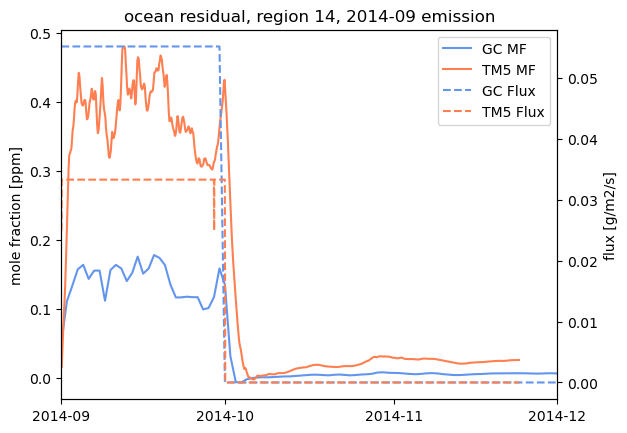

In [27]:
tm5c = 'coral'
gcc = 'cornflowerblue'

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(gc_data.time, gc_data.isel(lev=0).sel(lat=0, lon=-100, method='nearest'), color=gcc, label='GC MF')
ax.plot(tm5_mf.time, tm5_mf.isel(level=0).sel(latitude=0, longitude=-100, method='nearest'), color=tm5c, label='TM5 MF')
ax.plot(gc_data.time[0], [0], '--', color=gcc, label='GC Flux')
ax.plot(tm5_mf.time[0], [0], '--', color=tm5c, label='TM5 Flux')

axf = plt.gca().twinx()
axf.plot(gc_flux.time, gc_flux.sel(lat=0, lon=-100, method='nearest'), '--', color=gcc)
axf.plot(tm5_flux.time, tm5_flux.sel(latitude=0, longitude=-100, method='nearest'), '--', color=tm5c)

ax.set_xlim([np.datetime64('2014-09-01'), np.datetime64('2014-12-01')])
ax.set_title('ocean residual, region 14, 2014-09 emission, level=0, lat=0, lon=-100'')
ax.set_ylabel('mole fraction [ppm]')
axf.set_ylabel('flux [g/m2/s]')
ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))